Importación de paquetes necesarios

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import shap 

Importación de los dataframes curados con los compuestos y sus respectivos features

In [5]:
df_fisico = pd.read_csv('../data/processed/fisicoquimicos_filtrados.csv')
df_maccs = pd.read_csv('../data/processed/maccs_filtrados.csv')

Separamos las variables independientes (X) y la variable objetivo (y). La columna 'y' (pChEMBL_Value) es exactamente igual en ambos datasets, por lo que con importar una ya será suficiente.

In [6]:
y = df_maccs['pChEMBL_Value'].values
X_fisico = df_fisico.drop(columns=['pChEMBL_Value']).values
X_maccs = df_maccs.drop(columns=['pChEMBL_Value']).values

División Train/Test (80/20). Usamos el mismo random_state=42 para garantizar que las mismas moléculas caigan en Test para ambos modelos

In [7]:
X_train_fisiq, X_test_fisiq, y_train, y_test = train_test_split(X_fisico, y, test_size=0.2, random_state=42)
X_train_mac, X_test_mac, y_train, y_test = train_test_split(X_maccs, y, test_size=0.2, random_state=42)

Definimos y entrenamos los dos modelos Random Forest:

In [8]:
rf_fisico = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fisico.fit(X_train_fisiq, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
rf_maccs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_maccs.fit(X_train_mac, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Generamos las predicciones en el conjunto de prueba:

In [10]:
y_pred_fisico = rf_fisico.predict(X_test_fisiq)
y_pred_maccs = rf_maccs.predict(X_test_mac)

Evaluamos y comparamos los modelos independientes:

In [11]:
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.499
RMSE:     0.606


In [12]:
print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs)):.3f}")


--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.592
RMSE:     0.547


Estrategia de Consenso: Promediamos las predicciones de ambos modelos

In [13]:
y_pred_consenso = (y_pred_fisico + y_pred_maccs) / 2

print("\n--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso)):.3f}")


--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---
R2 Score: 0.584
RMSE:     0.552


Let's visualise the true vs the predicted values.

<Axes: xlabel='True', ylabel='Predicted'>

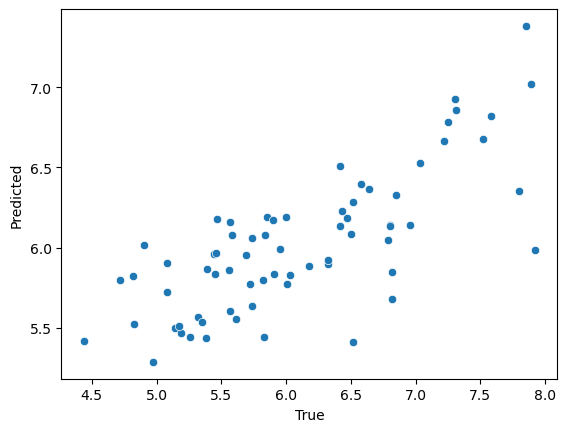

In [14]:
pred_fisico_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_fisico
     }
)
sns.scatterplot(data=pred_fisico_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

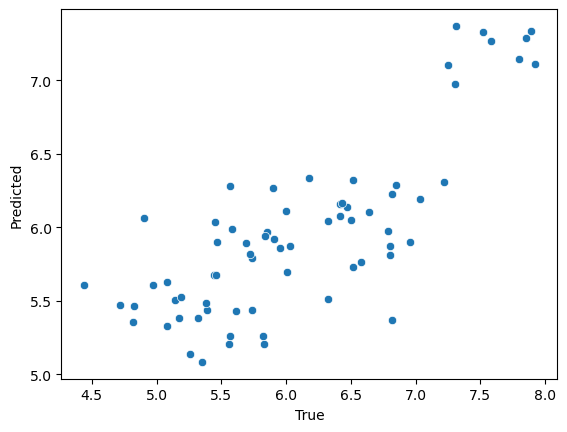

In [15]:
pred_maccs_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_maccs
     }
)
sns.scatterplot(data=pred_maccs_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

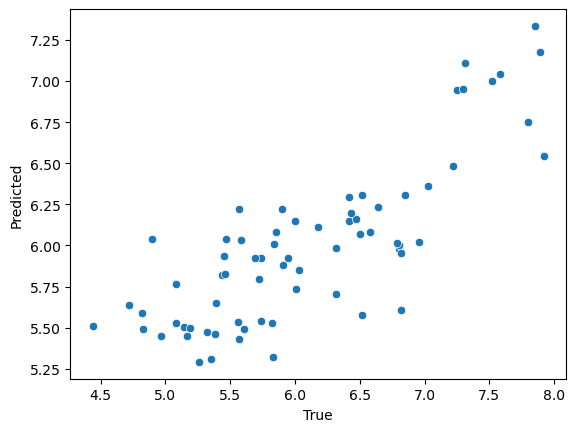

In [16]:
pred_consenso_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_consenso
     }
)
sns.scatterplot(data=pred_consenso_df, x="True", y="Predicted")

We are going to use a Random Forest Classifier to classify mitochondiral toxicity. We will
perform a 5 fold grid search cross validation to optimise the parameters of the Classifier.
We can choose between 200 and 300 trees, maximum features to be used in these trees, the
minimum samples to split a node, the maximum depth of a tree.
The taining data will be split into 5 groups and 4 of these will be trained on models varying
these parameters. This will be repeated 5 times and the best performing model's parameters are
stored in the best_estimator

In [17]:
# 1. Definimos la cuadrícula de hiperparámetros a optimizar (param_grid)
param_grid = {
    "n_estimators": [200, 300],              # Evaluamos si necesitas un bosque estándar o más denso
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 5],              # Control básico de ramificación
    "min_samples_leaf": [1, 2],               # Control básico de sobreajuste en las hojas
    "max_depth": [None, 10, 15],              # Puntos clave de profundidad
    'bootstrap': [True]                       # Mantenerlo True suele ser lo mejor en QSAR pequeños
}

In [18]:
# 2. Configuramos el Grid Search con 5-Fold Cross Validation para el modelo Fisicoquímico
print("Optimizando modelo Fisicoquímico (probando combinaciones)...")
grid_fisico = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=5,  
                           n_jobs=-1,  
                           verbose=1) 
grid_fisico.fit(X_train_fisiq, y_train)

Optimizando modelo Fisicoquímico (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [19]:
# 3. Configuramos el Grid Search para el modelo MACCS Keys
print("\nOptimizando modelo MACCS Keys (probando combinaciones)...")
grid_maccs = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                          param_grid=param_grid, 
                          cv=5, 
                          n_jobs=-1, 
                          verbose=1)
grid_maccs.fit(X_train_mac, y_train)


Optimizando modelo MACCS Keys (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [20]:
# 4. Extraemos los mejores hiperparámetros encontrados para cada modelo
print("\nMejores hiperparámetros Fisicoquímicos:", grid_fisico.best_params_)
print("Mejores hiperparámetros MACCS:", grid_maccs.best_params_)


Mejores hiperparámetros Fisicoquímicos: {'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejores hiperparámetros MACCS: {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [21]:
# 5. Extraemos los modelos ya optimizados automáticamente por Grid Search
best_rf_fisico = grid_fisico.best_estimator_
best_rf_maccs = grid_maccs.best_estimator_

In [22]:
# 6. Generamos las nuevas predicciones optimizadas aplicándolas a los datos de Prueba (Test)
y_pred_fisico_opt = best_rf_fisico.predict(X_test_fisiq)
y_pred_maccs_opt = best_rf_maccs.predict(X_test_mac)

In [23]:
# 7. Calculamos el nuevo Consenso (promedio de las predicciones de los mejores modelos)
y_pred_consenso_opt = (y_pred_fisico_opt + y_pred_maccs_opt) / 2

In [24]:
# 8. Evaluamos el Consenso Final de los modelos Optimizados
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso_opt)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.494
RMSE:     0.609

--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.543
RMSE:     0.579

--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---
R2 Score: 0.543
RMSE:     0.579


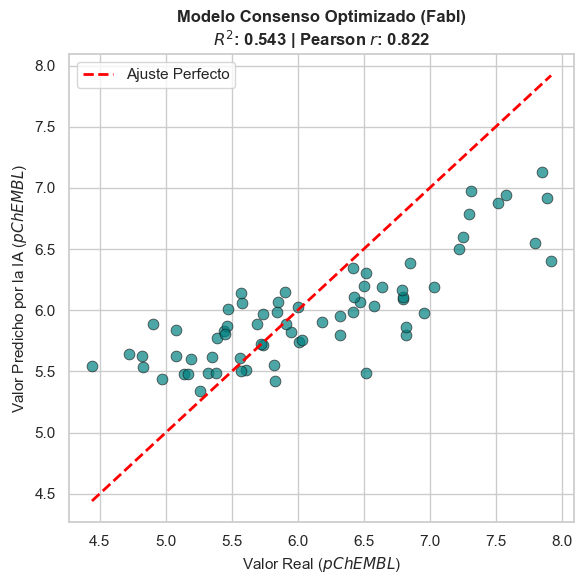

In [25]:
# 1. Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Dibujamos los puntos (Real vs Predicho del Consenso)
sns.scatterplot(x=y_test, y=y_pred_consenso_opt, alpha=0.7, color='teal', edgecolor='k', s=60)

# 3. Dibujamos la línea de ajuste perfecto (diagonal)
p1 = max(max(y_test), max(y_pred_consenso_opt))
p2 = min(min(y_test), min(y_pred_consenso_opt))
plt.plot([p2, p1], [p2, p1], color='red', linestyle='--', linewidth=2, label="Ajuste Perfecto")

# 4. Calculamos la correlación de Pearson para la gráfica
r_val, _ = pearsonr(y_test, y_pred_consenso_opt)

# 5. Títulos y etiquetas (Aseguramos que muestre tu R² real de 0.543)
plt.title(f"Modelo Consenso Optimizado (FabI)\n$R^2$: {0.543:.3f} | Pearson $r$: {r_val:.3f}", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real ($pChEMBL$)", fontsize=11)
plt.ylabel("Valor Predicho por la IA ($pChEMBL$)", fontsize=11)
plt.legend(loc="upper left")

# 6. Ajustamos márgenes y guardamos
plt.tight_layout()
plt.savefig("correlacion_consenso_qsar.png", dpi=300)
plt.show()

Interpretación de los resultados de predicción del modelo: Sabemos cómo predice el modelo, pero no por qué se llega a un resultado u otro, ni qué descriptores han tenido más peso en el valor de ChEBML predicho. Para poder interpretar los resultados del modelo utilizaremos
SHAP, una herramienta que permite conocer cuánto contribuye cada descriptor a la predicción final.

Empezaremos con el modelo de deescriptores fisico-químicos.

In [52]:
# 1. Recuperamos los nombres de las columnas (quitando la variable objetivo si estuviera)
nombres_columnas = list(df_fisico.columns)
if 'pChEMBL_Value' in nombres_columnas: nombres_columnas.remove('pChEMBL_Value')

In [53]:
# 2. Forzamos que tu X_test vuelva a ser un DataFrame con sus nombres oficiales
X_test_fisiq_df = pd.DataFrame(X_test_fisiq, columns=nombres_columnas)

In [54]:
# 3. 
explainer = shap.Explainer(best_rf_fisico, X_test_fisiq_df)
shap_values_fisiq = explainer(X_test_fisiq_df)

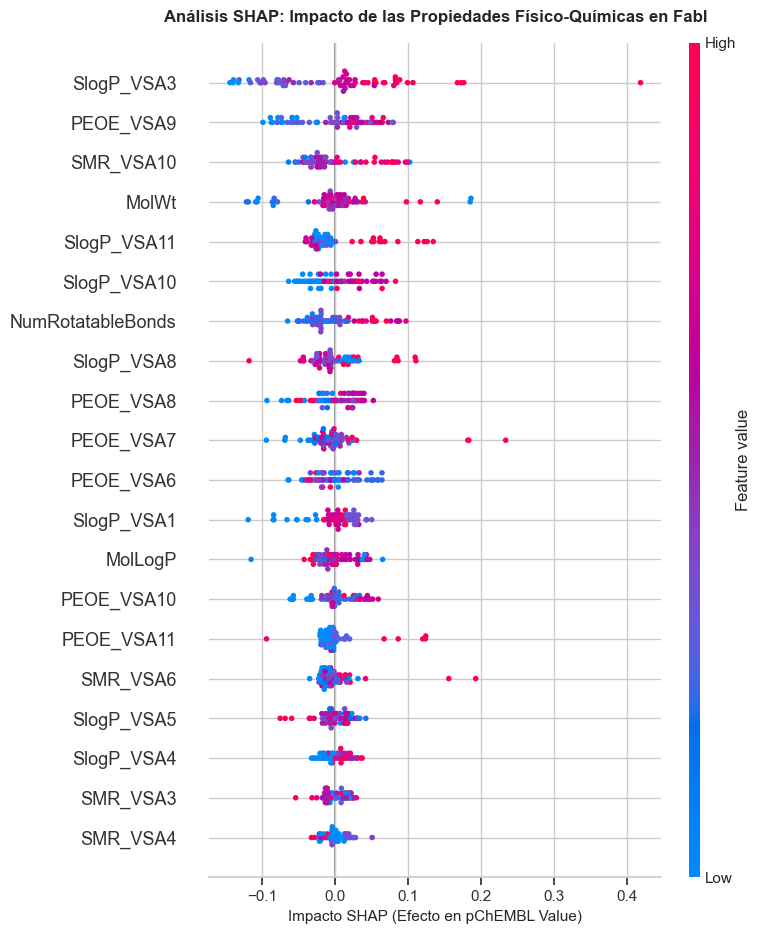

In [55]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_fisiq, 
    X_test_fisiq, 
    max_display=20,    # Mostramos los 15 descriptores físico-químicos más influyentes
    plot_type="dot",   # Forzamos nubes de puntos (azules/rojos)
    feature_names=nombres_columnas,
    show=False
)
# Ajustes estéticos finales
plt.title("Análisis SHAP: Impacto de las Propiedades Físico-Químicas en FabI", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Impacto SHAP (Efecto en pChEMBL Value)", fontsize=11)
plt.tight_layout()
# Guardamos la gráfica limpia para tu documento
plt.savefig("shap_summary_fisicoquimicos.png", dpi=300)
plt.show()

In [61]:
# 1. Calculamos la importancia global como la media del valor absoluto de SHAP
importancias_shap = np.abs(shap_values_fisiq.values).mean(axis=0)

# 2. Creamos un DataFrame emparejando el nombre del descriptor con su valor
df_ranking_shap = pd.DataFrame({
    'Descriptor': X_test_fisiq_df.columns,
    'Importancia_SHAP': importancias_shap
})

# 3. Lo ordenamos de mayor a menor importancia
df_ranking_shap = df_ranking_shap.sort_values(by='Importancia_SHAP', ascending=False).reset_index(drop=True)

# 4. Guardamos a CSV con formato compatible para tu Excel en español
df_ranking_shap.round(4).to_csv("ranking_importancia_SHAP.csv", sep=';', decimal=',', index=False)

print("¡Lista de importancia SHAP guardada con éxito!")
print(df_ranking_shap.head(21)) 

¡Lista de importancia SHAP guardada con éxito!
           Descriptor  Importancia_SHAP
0          SlogP_VSA3          0.069318
1           PEOE_VSA9          0.040726
2           SMR_VSA10          0.035177
3               MolWt          0.034214
4         SlogP_VSA11          0.031266
5         SlogP_VSA10          0.030676
6   NumRotatableBonds          0.030423
7          SlogP_VSA8          0.025120
8           PEOE_VSA8          0.024673
9           PEOE_VSA7          0.024582
10          PEOE_VSA6          0.024307
11         SlogP_VSA1          0.022452
12            MolLogP          0.020685
13         PEOE_VSA10          0.020199
14         PEOE_VSA11          0.017832
15           SMR_VSA6          0.017313
16         SlogP_VSA5          0.015744
17         SlogP_VSA4          0.013807
18           SMR_VSA3          0.013120
19           SMR_VSA4          0.011109
20          PEOE_VSA2          0.010208


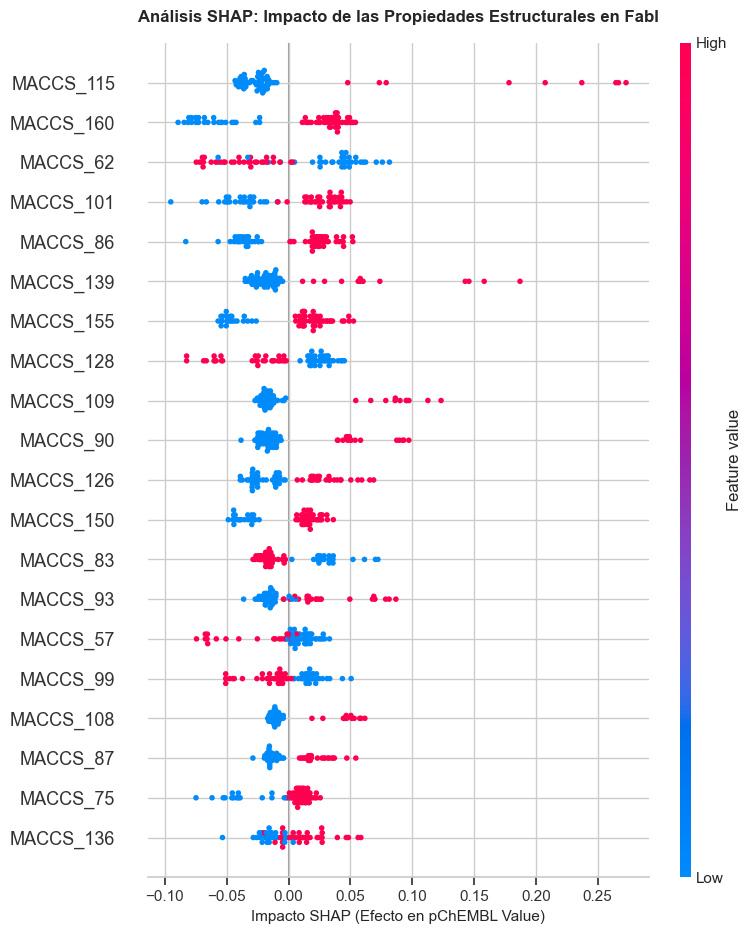

In [64]:
# Repetimos lo mismo con el otro modelo
nombres_maccs = [col for col in df_maccs.columns if col not in ['Smiles', 'pChEMBL_Value', 'pChEMBL Value']]
X_test_mac_df = pd.DataFrame(X_test_mac, columns=nombres_maccs)
explainer = shap.Explainer(best_rf_maccs, X_test_mac)
shap_values_mac = explainer(X_test_mac_df)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mac, 
    X_test_mac, 
    max_display=20,    # Mostramos los 15 descriptores físico-químicos más influyentes
    plot_type="dot",   # Forzamos nubes de puntos (azules/rojos)
    show=False
)
# Ajustes estéticos finales
plt.title("Análisis SHAP: Impacto de las Propiedades Estructurales en FabI", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Impacto SHAP (Efecto en pChEMBL Value)", fontsize=11)
plt.tight_layout()
# Guardamos la gráfica limpia para tu documento
plt.savefig("shap_summary_maccs.png", dpi=300)
plt.show()

In [66]:
# 1. Calculamos la importancia global usando los valores del objeto SHAP moderno
importancias_shap = np.abs(shap_values_mac.values).mean(axis=0)

# 2. Creamos el DataFrame usando las columnas del DataFrame que sí tiene los nombres
df_ranking_shap = pd.DataFrame({
    'Descriptor': X_test_mac_df.columns,  # <-- CORREGIDO: Usamos el DataFrame de Pandas
    'Importancia_SHAP': importancias_shap
})

# 3. Lo ordenamos de mayor a menor importancia
df_ranking_shap = df_ranking_shap.sort_values(by='Importancia_SHAP', ascending=False).reset_index(drop=True)

# 4. Guardamos a CSV con formato compatible para tu Excel
df_ranking_shap.round(4).to_csv("ranking_importancia_SHAP_maccs.csv", sep=';', decimal=',', index=False)

print("¡Lista de importancia SHAP de MACCS Keys guardada con éxito!")
print(df_ranking_shap.head(21))

¡Lista de importancia SHAP de MACCS Keys guardada con éxito!
   Descriptor  Importancia_SHAP
0   MACCS_115          0.047194
1   MACCS_160          0.044395
2    MACCS_62          0.041572
3   MACCS_101          0.033936
4    MACCS_86          0.031120
5   MACCS_139          0.030275
6   MACCS_155          0.029265
7   MACCS_128          0.028887
8   MACCS_109          0.028599
9    MACCS_90          0.027259
10  MACCS_126          0.024926
11  MACCS_150          0.023620
12   MACCS_83          0.022240
13   MACCS_93          0.021588
14   MACCS_57          0.018118
15   MACCS_99          0.017745
16  MACCS_108          0.017631
17   MACCS_87          0.017182
18   MACCS_75          0.017169
19  MACCS_136          0.016521
20   MACCS_95          0.014609
